In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [22]:
data = pd.read_csv('Salary_Data.csv')

In [23]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


<Figure size 300x300 with 0 Axes>

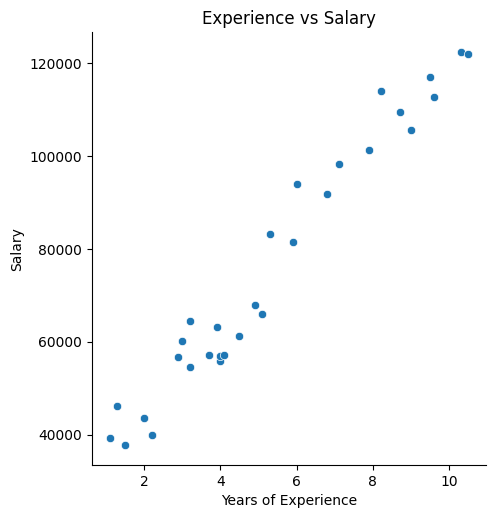

In [24]:
plt.figure(figsize=(3,3))
sns.pairplot(data, x_vars=['YearsExperience'], y_vars='Salary', height=5, aspect=1, kind='scatter')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

In [25]:
x = data.iloc[:,:-1]
y = data.iloc[:,1]
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [26]:
y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10, shuffle=True) 

In [28]:
x_train

,YearsExperience
13,4.1
27,9.6
12,4.0
1,1.3
19,6.0
14,4.5
18,5.9
6,3.0
11,4.0
23,8.2


In [29]:
x_test

,YearsExperience
20,6.8
7,3.2
5,2.9
2,1.5
3,2.0
21,7.1


In [30]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0.5, 1.0, 'Linear Regression Fit on Training Data')

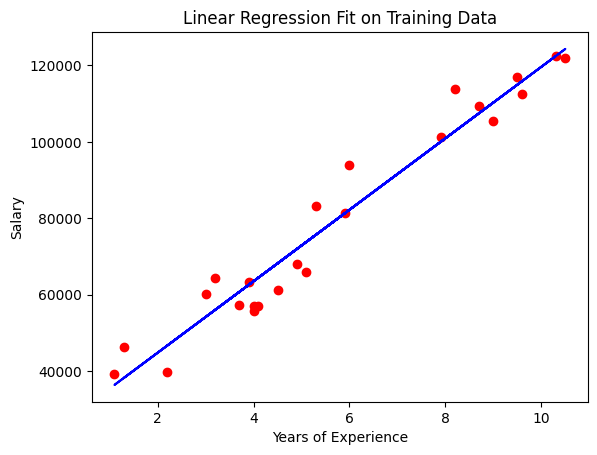

In [31]:
plt.scatter(x_train, y_train, color='red', label='Training Data')
plt.plot(x_train, linear_model.predict(x_train), color='blue', label='Linear Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Fit on Training Data')

Text(0.5, 1.0, 'Linear Regression Fit on Test Data')

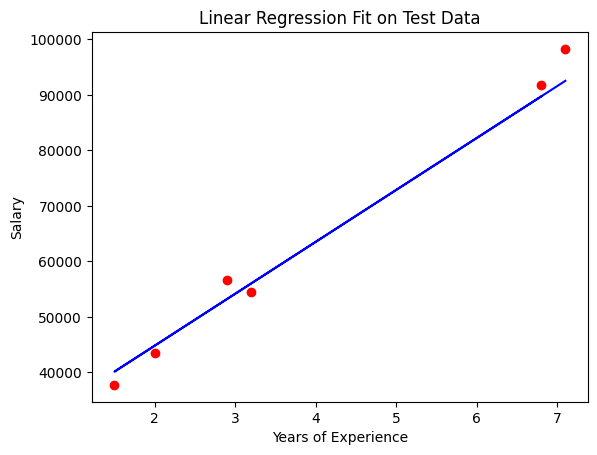

In [32]:
plt.scatter(x_test, y_test, color='red', label='Test Data')
plt.plot(x_test, linear_model.predict(x_test), color='blue', label='Linear Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Fit on Test Data')

In [ ]:
#MSR, rmse: model / error
# represent the average squared difference between the predicted and actual values

#r-squared: 1- (model / co varience)
# represent varience explained by the model
# 1: perfect fit, 0: no fit, negative: worse than mean

In [33]:
#calculate the mean squared error and R-squared score
y_pred = linear_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 9785570.14
Root Mean Squared Error: 3128.19
R-squared Score: 0.98


In [35]:
linear_model.intercept_ 

np.float64(26089.096632416724)

In [36]:
linear_model.coef_

array([9356.86299354])

In [37]:
x = float(input('Enter years of experience: '))
predicted_salary = linear_model.predict([[x]])
print(f'Predicted salary for {x} years of experience: ${predicted_salary[0]:.2f}')

Predicted salary for 6.3 years of experience: $85037.33
